Part A:
Line: y = 0.9500000000000005 *x + 0.5900000000000003
Cubic coeff: [ 0.04166667 -0.51071429  2.74761905 -1.06      ]
Line  MSE/R2: 0.061400000000000135 0.9671024432061722
Cubic MSE/R2: 0.004828571428571433 0.9974128957197967
Better: Cubic
Part B:
deg 1 MSE 0.06140000000000003 R2 0.9671024432061723
deg 2 MSE 0.009828571428571433 R2 0.9947339415834915
deg 3 MSE 0.004828571428571433 R2 0.9974128957197967
deg 4 MSE 3.1661918507176836e-28 R2 1.0
deg 5 MSE 1.2366380765470885e-28 R2 1.0
deg 6 MSE 4.230266604247676e-30 R2 1.0
deg 7 MSE 7.85902676826433e-30 R2 1.0
deg 8 MSE 1.538278765180973e-29 R2 1.0
deg 9 MSE 8.756356047953231e-30 R2 1.0
deg 10 MSE 4.4462172770519276e-29 R2 1.0
Part C:
a0..a3: [-1.06        2.74761905 -0.51071429  0.04166667]
MSE/R2: 0.00482857142857143 0.9974128957197967


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly co

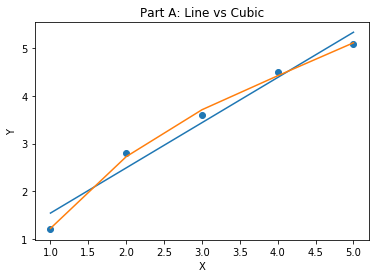

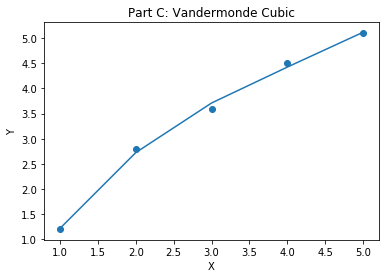

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import random

X = np.array([1,2,3,4,5], float)
Y = np.array([1.2,2.8,3.6,4.5,5.1], float)
ind = random.permutation(len(X))
X, Y = X[ind], Y[ind]
mse  = lambda y, yp: np.mean((y-yp)**2)
r2   = lambda y, yp: 1 - np.sum((y-yp)**2)/np.sum((y-np.mean(y))**2)

#Part A--------------------------------------------------------------------------------------------
A = np.column_stack((X, np.ones(len(X))))
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
y_line = m*X + c
p3 = np.poly1d(np.polyfit(X, Y, 3))
y_poly3 = p3(X)
print("Part A:")
print("Line: y =", m, "*x +", c)
print("Cubic coeff:", p3.c)
print("Line  MSE/R2:", mse(Y,y_line),  r2(Y,y_line))
print("Cubic MSE/R2:", mse(Y,y_poly3), r2(Y,y_poly3))

if mse(Y,y_poly3) < mse(Y,y_line):
    print("Better: Cubic")
else:
    print("Better: Line")
xs = np.sort(X)
plt.figure()
plt.scatter(X, Y)
plt.plot(xs, m*xs + c)
plt.plot(xs, p3(xs))
plt.title("Part A: Line vs Cubic")
plt.xlabel("X"); plt.ylabel("Y")

#Part B---------------------------------------------------------------------------------------------
print("Part B:")
for d in range(1, 11):
    pd = np.poly1d(np.polyfit(X, Y, d))
    yp = pd(X)
    print("deg", d, "MSE", mse(Y,yp), "R2", r2(Y,yp))

#Part C----------------------------------------------------------------------------------------------
deg = 3
V = np.vander(X, N=deg+1, increasing=True)
a = np.linalg.lstsq(V, Y, rcond=None)[0]
y_v = V @ a
print("Part C:")
print("a0..a3:", a)
print("MSE/R2:", mse(Y,y_v), r2(Y,y_v))

plt.figure()
plt.scatter(X, Y)
Vxs = np.vander(xs, N=deg+1, increasing=True)
plt.plot(xs, Vxs @ a)
plt.title("Part C: Vandermonde Cubic")
plt.xlabel("X"); plt.ylabel("Y")
plt.show()